In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:

# Load model-ready dataset
model_df = pd.read_csv("final_dataset_model_ready.csv")

# Parse only UTC datetime for sorting and splitting
# Keep datetime_dk as reference
model_df["datetime_utc"] = pd.to_datetime(model_df["datetime_utc"], utc=True)

# Sort by UTC time
model_df = model_df.sort_values("datetime_utc").reset_index(drop=True)

print("Shape:", model_df.shape)
print("Time range:", model_df["datetime_utc"].min(), "to", model_df["datetime_utc"].max())

model_df.head()

Shape: (26135, 28)
Time range: 2022-01-08 01:00:00+00:00 to 2024-12-31 23:00:00+00:00


,datetime_utc,GrossConsumptionMWh,co2_intensity,temperature,wind_speed,solar_radiation,datetime_dk,hour,day_of_week,month,...,cons_lag_24,cons_lag_168,wind_lag1,solar_lag1,renewables_lag1,conventional_lag1,production_lag1,imports_lag1,exports_lag1,netexchange_lag1
0,2022-01-08 01:00:00+00:00,2217.258014,237.916667,0.366667,4.650000,0.000000,2022-01-08 02:00:00+01:00,2,5,1,...,2652.991549,2147.758315,1514.506265,0.020231,1517.366409,1769.893677,3287.260086,706.557,1738.8374,-1032.2804
1,2022-01-08 02:00:00+00:00,2205.778739,200.916667,0.250000,4.516667,0.000000,2022-01-08 03:00:00+01:00,3,5,1,...,2624.932058,2023.389045,1591.529154,0.019312,1594.388571,1754.047443,3348.436014,715.928,1847.1060,-1131.1780
2,2022-01-08 03:00:00+00:00,2215.918726,181.083333,0.183333,4.466667,0.166667,2022-01-08 04:00:00+01:00,4,5,1,...,2518.178217,2050.223766,2047.264690,0.020917,2050.111242,1630.835297,3680.946539,699.532,2174.6998,-1475.1678
3,2022-01-08 04:00:00+00:00,2261.391988,205.833333,0.400000,4.616667,0.500000,2022-01-08 05:00:00+01:00,5,5,1,...,2812.590459,2065.765754,2061.370262,0.019702,2064.214709,1443.523017,3507.737726,689.025,1980.8440,-1291.8190
4,2022-01-08 05:00:00+00:00,2397.376598,177.583333,-0.083333,4.283333,1.000000,2022-01-08 06:00:00+01:00,6,5,1,...,3110.981584,2084.435142,2085.914585,0.019528,2088.762961,1722.795627,3811.558588,303.870,1854.0366,-1550.1666


The UTC timestamp was used for sorting and splitting because it provides a stable and continuous hourly timeline, unaffected by daylight saving time changes. The Danish local timestamp was retained for reference and interpretation but was not used for temporal splitting.

## Forecasting Setup and Feature Availability

This study adopts a one-hour-ahead forecasting setup for electricity consumption and CO₂ intensity in DK1. For each hourly observation, the objective is to predict the target value for the forecast hour using only information that would be available before or at the time of prediction.

To reduce the risk of data leakage, contemporaneous system variables such as electricity production, renewable generation, imports, exports, and net exchange are not used directly as predictors. Instead, these variables are included only through lagged values, mainly lag-1, representing the most recently observed system state. Similarly, lagged values of electricity consumption and CO₂ intensity are included to capture short-term persistence, daily seasonality, and weekly patterns.

Calendar-based variables such as hour of day, day of week, month, weekend indicator, and season are retained because they are known in advance and do not introduce look-ahead bias.

Weather variables, including temperature, wind speed, and solar radiation, are included under the assumption that short-term weather forecasts are available for the forecast hour. In the empirical implementation, observed weather values are used as proxies for these forecasted weather inputs. Therefore, the reported performance should be interpreted as an idealized or upper-bound forecasting scenario rather than a fully operational forecast using real-time weather forecasts.

This distinction is important because the models do not use future target values or contemporaneous production and exchange variables, but they do assume access to accurate short-term weather information. Consequently, the results evaluate the predictive value of the selected feature set under controlled conditions, while actual operational performance may be slightly lower if weather forecast errors are introduced.

The empirical setup should therefore be interpreted as a leakage-controlled, idealized one-hour-ahead forecasting experiment rather than a fully operational real-time deployment.

In [3]:
print(model_df.dtypes)

datetime_utc           datetime64[us, UTC]
GrossConsumptionMWh                float64
co2_intensity                      float64
temperature                        float64
wind_speed                         float64
solar_radiation                    float64
datetime_dk                            str
hour                                 int64
day_of_week                          int64
month                                int64
is_weekend                           int64
season_spring                        int64
season_summer                        int64
season_winter                        int64
co2_lag_1                          float64
co2_lag_24                         float64
co2_lag_168                        float64
cons_lag_1                         float64
cons_lag_24                        float64
cons_lag_168                       float64
wind_lag1                          float64
solar_lag1                         float64
renewables_lag1                    float64
conventiona

## Modelling Strategy

Two complementary modelling specifications are considered in this study.

The first specification includes lagged target variables, including lag-1 features, and is designed to maximize short-term forecasting accuracy. This setup represents the primary predictive modelling framework used for evaluating forecasting performance.

The second specification excludes the lag-1 target variable. The purpose of this setup is not to improve predictive accuracy, but to examine how the models utilize other predictors such as weather variables, lagged system variables, and calendar features when immediate persistence information is restricted.

This dual modelling strategy allows the analysis to distinguish between predictive performance and interpretability.

In [4]:

# Time-aware train/validation/test split

train_df = model_df[model_df["datetime_utc"] < "2023-10-01"].copy()

val_df = model_df[
    (model_df["datetime_utc"] >= "2023-10-01") &
    (model_df["datetime_utc"] < "2024-01-01")
].copy()

test_df = model_df[model_df["datetime_utc"] >= "2024-01-01"].copy()

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain range:", train_df["datetime_utc"].min(), "to", train_df["datetime_utc"].max())
print("Validation range:", val_df["datetime_utc"].min(), "to", val_df["datetime_utc"].max())
print("Test range:", test_df["datetime_utc"].min(), "to", test_df["datetime_utc"].max())

Train shape: (15143, 28)
Validation shape: (2208, 28)
Test shape: (8784, 28)

Train range: 2022-01-08 01:00:00+00:00 to 2023-09-30 23:00:00+00:00
Validation range: 2023-10-01 00:00:00+00:00 to 2023-12-31 23:00:00+00:00
Test range: 2024-01-01 00:00:00+00:00 to 2024-12-31 23:00:00+00:00


A strict time-aware validation strategy was used to preserve temporal ordering and avoid leakage from future observations. The dataset was divided into three consecutive periods: a training set covering January 2022 to September 2023, a validation set covering October to December 2023, and a final test set covering the entire year 2024.

This split ensures that all hyperparameter tuning and model selection are performed using past data only, while the 2024 test set remains untouched until final evaluation. As a result, the reported test performance provides an unbiased estimate of out-of-sample forecasting ability.

In [5]:
# Define target and features for electricity consumption

target = "GrossConsumptionMWh"

feature_cols = [col for col in model_df.columns if col not in [
    "GrossConsumptionMWh",
    "co2_intensity",
    "datetime_utc",
    "datetime_dk"
]]

X_train = train_df[feature_cols]
X_val = val_df[feature_cols]
X_test = test_df[feature_cols]

y_train = train_df[target]
y_val = val_df[target]
y_test = test_df[target]

print("Number of features:", len(feature_cols))
print("Feature names:")
print(feature_cols)

Number of features: 24
Feature names:
['temperature', 'wind_speed', 'solar_radiation', 'hour', 'day_of_week', 'month', 'is_weekend', 'season_spring', 'season_summer', 'season_winter', 'co2_lag_1', 'co2_lag_24', 'co2_lag_168', 'cons_lag_1', 'cons_lag_24', 'cons_lag_168', 'wind_lag1', 'solar_lag1', 'renewables_lag1', 'conventional_lag1', 'production_lag1', 'imports_lag1', 'exports_lag1', 'netexchange_lag1']


For electricity consumption forecasting, the predictor matrix excludes the raw datetime columns and both target variables from direct model input. The remaining features include weather variables, calendar-based variables, lagged target variables, and lagged production-related variables.

This feature design reflects the leakage-aware forecasting setup and ensures that only information available at prediction time is used by the models.

### Predictive Modelling Setup (with lag-1)

In [6]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [7]:
# Baseline models for electricity consumption

# Baseline 1: lag-1 persistence 
y_val_pred_baseline_lag1 = X_val["cons_lag_1"]
y_test_pred_baseline_lag1 = X_test["cons_lag_1"]

# Baseline 2: lag-24 persistence (daily seasonal benchmark)
y_val_pred_baseline_lag24 = X_val["cons_lag_24"]
y_test_pred_baseline_lag24 = X_test["cons_lag_24"]

# Validation metrics
val_mae_c_lag1 = mean_absolute_error(y_val, y_val_pred_baseline_lag1)
val_rmse_c_lag1 = np.sqrt(mean_squared_error(y_val, y_val_pred_baseline_lag1))

val_mae_c_lag24 = mean_absolute_error(y_val, y_val_pred_baseline_lag24)
val_rmse_c_lag24 = np.sqrt(mean_squared_error(y_val, y_val_pred_baseline_lag24))

# Test metrics
test_mae_c_lag1 = mean_absolute_error(y_test, y_test_pred_baseline_lag1)
test_rmse_c_lag1 = np.sqrt(mean_squared_error(y_test, y_test_pred_baseline_lag1))

test_mae_c_lag24 = mean_absolute_error(y_test, y_test_pred_baseline_lag24)
test_rmse_c_lag24 = np.sqrt(mean_squared_error(y_test, y_test_pred_baseline_lag24))

print("Consumption Baseline (lag-1) Validation MAE:", val_mae_c_lag1)
print("Consumption Baseline (lag-1) Validation RMSE:", val_rmse_c_lag1)
print("Consumption Baseline (lag-1) Test MAE:", test_mae_c_lag1)
print("Consumption Baseline (lag-1) Test RMSE:", test_rmse_c_lag1)

print("\nConsumption Baseline (lag-24) Validation MAE:", val_mae_c_lag24)
print("Consumption Baseline (lag-24) Validation RMSE:", val_rmse_c_lag24)
print("Consumption Baseline (lag-24) Test MAE:", test_mae_c_lag24)
print("Consumption Baseline (lag-24) Test RMSE:", test_rmse_c_lag24)

Consumption Baseline (lag-1) Validation MAE: 93.8624337554348
Consumption Baseline (lag-1) Validation RMSE: 120.67480526858644
Consumption Baseline (lag-1) Test MAE: 102.62963573167121
Consumption Baseline (lag-1) Test RMSE: 133.4598218945855

Consumption Baseline (lag-24) Validation MAE: 258.6727910792573
Consumption Baseline (lag-24) Validation RMSE: 338.6276025278619
Consumption Baseline (lag-24) Test MAE: 206.90496566382058
Consumption Baseline (lag-24) Test RMSE: 285.4594884934361


Two persistence-based baseline models were evaluated for 1-hour-ahead forecasting: a lag-1 baseline (previous hour) and a lag-24 baseline (same hour previous day).

The lag-1 baseline achieved substantially better performance than the lag-24 baseline, with a test MAE of 102.63 MWh compared to 206.90 MWh for lag-24. This indicates that short-term persistence is a much stronger predictor of electricity consumption than daily seasonality at the 1-hour forecasting horizon.

In [8]:
from sklearn.linear_model import LinearRegression

In [9]:

# Linear Regression Model

# Create model
lr_model = LinearRegression()

# Train model
lr_model.fit(X_train, y_train)

# Predict
y_val_pred_lr = lr_model.predict(X_val)
y_test_pred_lr = lr_model.predict(X_test)

# Evaluate
val_mae_lr = mean_absolute_error(y_val, y_val_pred_lr)
val_rmse_lr = np.sqrt(mean_squared_error(y_val, y_val_pred_lr))

test_mae_lr = mean_absolute_error(y_test, y_test_pred_lr)
test_rmse_lr = np.sqrt(mean_squared_error(y_test, y_test_pred_lr))

print("Linear Regression Validation MAE:", val_mae_lr)
print("Linear Regression Validation RMSE:", val_rmse_lr)

print("\nLinear Regression Test MAE:", test_mae_lr)
print("Linear Regression Test RMSE:", test_rmse_lr)

Linear Regression Validation MAE: 91.95636424097754
Linear Regression Validation RMSE: 115.34071724331275

Linear Regression Test MAE: 85.32874919623758
Linear Regression Test RMSE: 111.6189382140883


A linear regression model was implemented as a baseline statistical learning approach using lagged variables, weather features, and time-based predictors. The model achieves a test MAE of approximately 85 MWh, representing a substantial improvement over the lag-24 persistence baseline. However, the improvement relative to the lag-1 baseline is more modest, indicating that a large portion of the predictive power is driven by short-term temporal dependence. While some multicollinearity may be present among the predictors, this does not materially affect forecasting performance and is therefore not a primary concern in this context.

Although the original proposal referred to XGBoost, the empirical implementation uses scikit-learn’s GradientBoostingRegressor as the tree-based gradient boosting model. This choice keeps the modelling pipeline simple and transparent while still representing the gradient boosting model family. The distinction will be made explicit in the thesis.

In [10]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [11]:
# Gradient Boosting (Basic Model)

# Create model (simple default)
gb_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)

# Train model
gb_model.fit(X_train, y_train)

# Predict
y_val_pred_gb = gb_model.predict(X_val)
y_test_pred_gb = gb_model.predict(X_test)

# Evaluate

val_mae_gb = mean_absolute_error(y_val, y_val_pred_gb)
val_rmse_gb = np.sqrt(mean_squared_error(y_val, y_val_pred_gb))

test_mae_gb = mean_absolute_error(y_test, y_test_pred_gb)
test_rmse_gb = np.sqrt(mean_squared_error(y_test, y_test_pred_gb))

print("Gradient Boosting Validation MAE:", val_mae_gb)
print("Gradient Boosting Validation RMSE:", val_rmse_gb)

print("\nGradient Boosting Test MAE:", test_mae_gb)
print("Gradient Boosting Test RMSE:", test_rmse_gb)

Gradient Boosting Validation MAE: 70.0132659066799
Gradient Boosting Validation RMSE: 95.0359018494665

Gradient Boosting Test MAE: 68.97174468418673
Gradient Boosting Test RMSE: 96.92482624993254


An initial gradient boosting model was trained using standard hyperparameters as a baseline before tuning. The model achieves a test MAE of approximately 69 MWh and an RMSE of approximately 96 MWh, improving over both the lag-24 baseline and linear regression. However, the improvement relative to the lag-1 baseline is more moderate, indicating that short-term persistence remains a dominant source of predictive power. The similar performance on validation and test sets suggests that the model generalizes reasonably well, although this does not fully rule out reliance on strong autoregressive structure.

In [12]:
# Simple Hyperparameter Tuning

results = []

for n in [100, 200]:
    for depth in [3, 5]:
        for lr in [0.05, 0.1]:
            
            model = GradientBoostingRegressor(
                n_estimators=n,
                max_depth=depth,
                learning_rate=lr,
                random_state=42
            )
            
            model.fit(X_train, y_train)
            y_val_pred = model.predict(X_val)
            
            mae = mean_absolute_error(y_val, y_val_pred)
            
            results.append((n, depth, lr, mae))

# Convert to DataFrame
results_df = pd.DataFrame(results, columns=["n_estimators", "max_depth", "learning_rate", "val_mae"])

# Sort results
results_df = results_df.sort_values(by="val_mae")

results_df.head(10)

,n_estimators,max_depth,learning_rate,val_mae
2,100,5,0.05,68.119112
5,200,3,0.10,69.797199
1,100,3,0.10,70.013266
4,200,3,0.05,70.160953
6,200,5,0.05,70.564288
3,100,5,0.10,71.612653
7,200,5,0.10,74.521493
0,100,3,0.05,74.624871


Hyperparameter tuning was performed using the validation set while preserving temporal ordering. Different combinations of the number of estimators, tree depth, and learning rate were evaluated.

The best-performing configuration is selected based on validation MAE. The final model was then retrained using both the training and validation datasets to maximize the use of available historical information.

The final model was evaluated on the untouched test set (year 2024), ensuring an unbiased estimate of out-of-sample forecasting performance.

In [13]:
# Train Final Model

# Combine train + validation
X_train_full = pd.concat([X_train, X_val])
y_train_full = pd.concat([y_train, y_val])

# Best parameters from tuning
best_model = GradientBoostingRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42
)

# Train on full data
best_model.fit(X_train_full, y_train_full)

# Final prediction on test
y_test_pred_final = best_model.predict(X_test)

# Final evaluation

final_mae = mean_absolute_error(y_test, y_test_pred_final)
final_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred_final))

print("FINAL MODEL TEST MAE:", final_mae)
print("FINAL MODEL TEST RMSE:", final_rmse)

FINAL MODEL TEST MAE: 65.13398760969487
FINAL MODEL TEST RMSE: 92.48962826851438


After hyperparameter tuning, the final gradient boosting model achieves a test MAE of approximately 65 MWh and an RMSE of approximately 93 MWh, indicating a modest improvement over the initial model. While this suggests that tuning enhances predictive performance.

            feature  importance
13       cons_lag_1    0.951236
3              hour    0.030933
15     cons_lag_168    0.007107
14      cons_lag_24    0.003005
2   solar_radiation    0.002433
4       day_of_week    0.001076
17       solar_lag1    0.000821
16        wind_lag1    0.000786
6        is_weekend    0.000441
1        wind_speed    0.000345


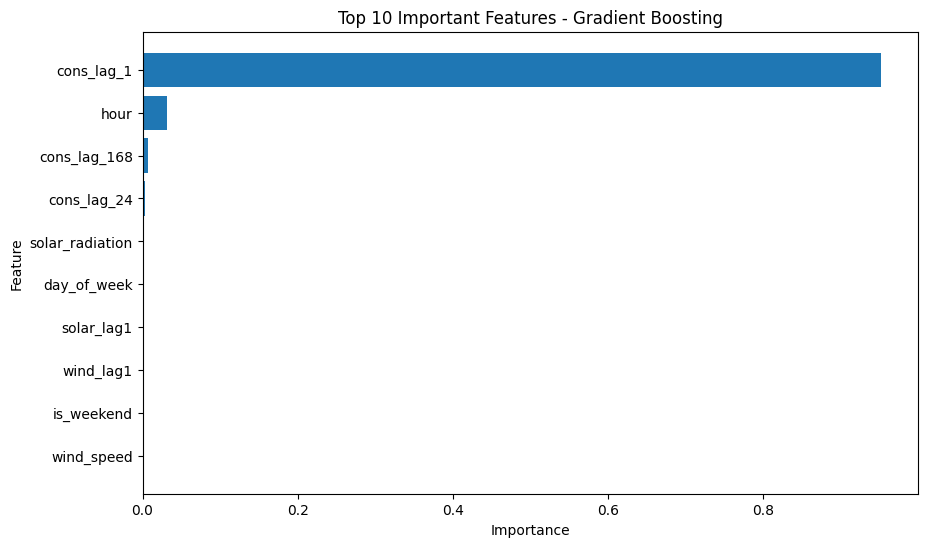

In [14]:
# Feature Importance

# Feature importance from the trained final model
importance = best_model.feature_importances_

# Create table
feat_imp = pd.DataFrame({
    "feature": feature_cols,
    "importance": importance
}).sort_values(by="importance", ascending=False)

# Show top 10
print(feat_imp.head(10))

# Plot top 10
plt.figure(figsize=(10, 6))
top10 = feat_imp.head(10).sort_values(by="importance", ascending=True)
plt.barh(top10["feature"], top10["importance"])
plt.title("Top 10 Important Features - Gradient Boosting")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

The feature importance analysis indicates that consumption lag-1 (cons_lag_1) overwhelmingly dominates the model, accounting for approximately 95% of the total importance. This suggests that short-term temporal dependence is the primary predictor used by the model.

All other features contribute only marginally. Among them, hour of day has a small but noticeable influence, suggesting the presence of daily patterns. Longer-term lags (lag-24 and lag-168) and weather-related variables (e.g., wind speed and solar radiation) exhibit very limited importance in comparison.

Overall, these results suggest that the model relies predominantly on autoregressive structure, with additional variables providing only minor incremental information when lag-1 is included.

In [15]:
import shap

In [16]:
# SHAP Analysis

# Create explainer
explainer = shap.Explainer(best_model, X_train)

# Calculate SHAP values (use a sample to make it faster)
X_sample = X_test.sample(1000, random_state=42)

shap_values = explainer(X_sample) 

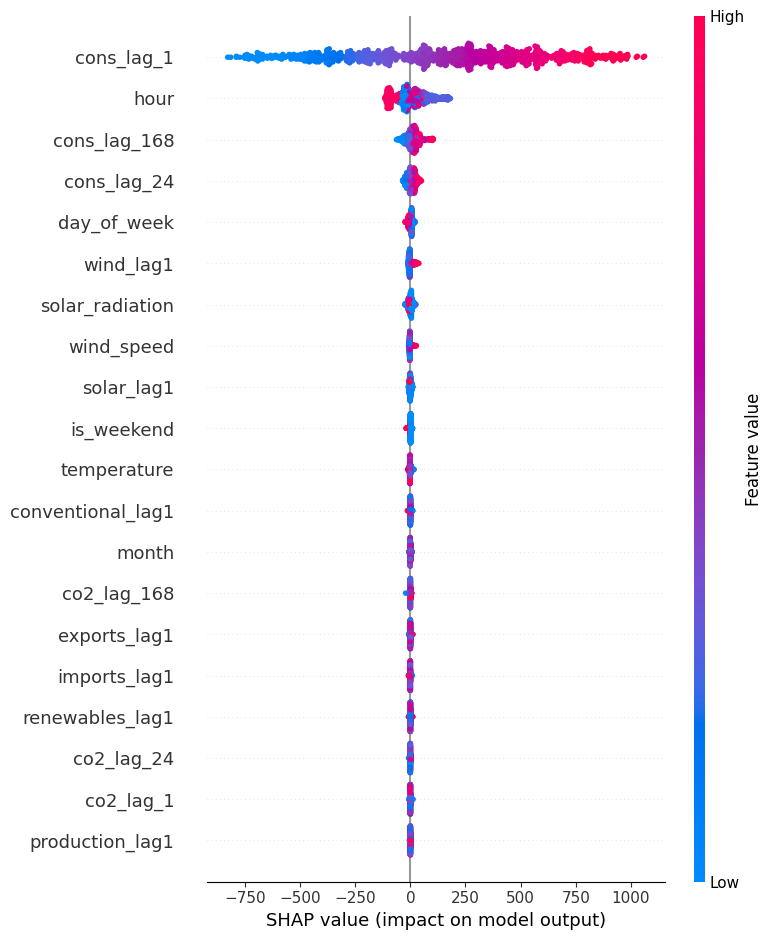

In [17]:
# SHAP Summary Plot
shap.summary_plot(shap_values, X_sample)

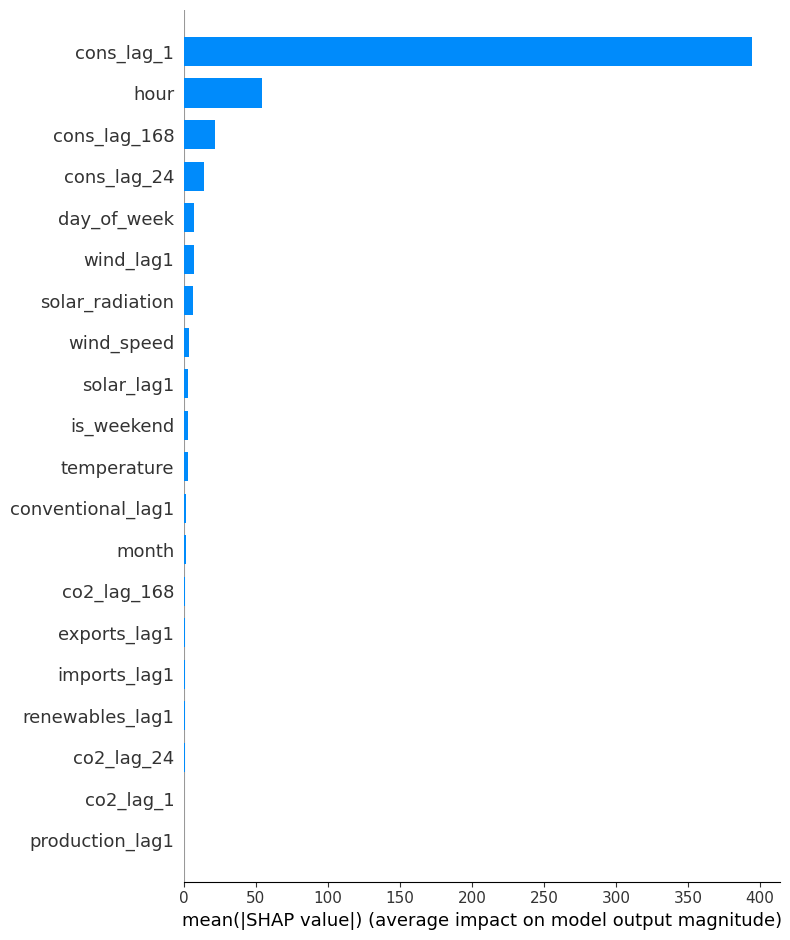

In [18]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

The SHAP analysis provides a descriptive view of how the fitted gradient boosting model uses the available predictors. Consistent with the feature-importance results, consumption lag-1 dominates the model output.

All remaining variables have comparatively small SHAP values once lag-1 is included. This indicates that, in the predictive specification, the model relies mainly on short-term autoregressive structure, while other predictors provide limited additional information.

These SHAP values should not be interpreted causally, especially because several predictors are correlated and lagged target variables dominate the model.

### Diagnostic Modelling Setup (without lag-1)

In [19]:
# Experiment: remove cons_lag_1

feature_cols_no_lag1 = [col for col in feature_cols if col != "cons_lag_1"]

X_train_no_lag1 = train_df[feature_cols_no_lag1]
X_val_no_lag1 = val_df[feature_cols_no_lag1]
X_test_no_lag1 = test_df[feature_cols_no_lag1]

print("Number of features without cons_lag_1:", len(feature_cols_no_lag1))
print(feature_cols_no_lag1)

Number of features without cons_lag_1: 23
['temperature', 'wind_speed', 'solar_radiation', 'hour', 'day_of_week', 'month', 'is_weekend', 'season_spring', 'season_summer', 'season_winter', 'co2_lag_1', 'co2_lag_24', 'co2_lag_168', 'cons_lag_24', 'cons_lag_168', 'wind_lag1', 'solar_lag1', 'renewables_lag1', 'conventional_lag1', 'production_lag1', 'imports_lag1', 'exports_lag1', 'netexchange_lag1']


Model Without Lag-1 Feature
To evaluate the importance of short-term temporal dependence, the lag-1 consumption feature was removed from the feature set. 
This experiment allows assessment of how much predictive performance depends on immediate past values versus longer-term temporal structures and external factors.

In [20]:
results = []

for n_estimators in [100, 200]:
    for max_depth in [3, 5]:
        for lr in [0.05, 0.1]:
            
            model = GradientBoostingRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=lr,
                random_state=42
            )
            
            model.fit(X_train_no_lag1, y_train)
            
            val_pred = model.predict(X_val_no_lag1)
            val_mae = mean_absolute_error(y_val, val_pred)
            
            results.append({
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "learning_rate": lr,
                "val_mae": val_mae
            })

results_df = pd.DataFrame(results).sort_values("val_mae")
print(results_df)

   n_estimators  max_depth  learning_rate     val_mae
7           200          5           0.10  122.753970
5           200          3           0.10  133.057860
3           100          5           0.10  133.538557
6           200          5           0.05  134.104962
2           100          5           0.05  150.778598
1           100          3           0.10  153.593839
4           200          3           0.05  153.737493
0           100          3           0.05  183.111074


An additional tuning experiment was conducted after removing the lag-1 consumption feature. The same time-aware training, validation, and test split was preserved to ensure a fair comparison and to avoid data leakage.

The best-performing configuration for the reduced feature set used 200 estimators, a maximum tree depth of 5, and a learning rate of 0.10. However, validation performance was substantially worse than in the original model, indicating that the lag-1 feature contains critical short-term information for electricity consumption forecasting.

In [21]:
# Final model without cons_lag_1

# Combine train + validation
X_train_full_no_lag1 = pd.concat([X_train_no_lag1, X_val_no_lag1])
y_train_full_no_lag1 = pd.concat([y_train, y_val])

# Best model from tuning
best_model_no_lag1 = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.10,
    random_state=42
)

# Train
best_model_no_lag1.fit(X_train_full_no_lag1, y_train_full_no_lag1)

# Predict on test
y_test_pred_no_lag1 = best_model_no_lag1.predict(X_test_no_lag1)

# Evaluate
test_mae_no_lag1 = mean_absolute_error(y_test, y_test_pred_no_lag1)
test_rmse_no_lag1 = np.sqrt(mean_squared_error(y_test, y_test_pred_no_lag1))

print("No-lag1 Final Test MAE:", test_mae_no_lag1)
print("No-lag1 Final Test RMSE:", test_rmse_no_lag1)

No-lag1 Final Test MAE: 107.54200155251492
No-lag1 Final Test RMSE: 145.85165094690115


Impact of Lag-1 Feature on Model Performance: To further investigate the role of short-term temporal dependence, an additional experiment was conducted by removing the lag-1 consumption feature from the model.

The results show a substantial degradation in predictive performance. The test MAE increased from approximately 65 to 108, and the RMSE increased from approximately 92 to 146.

These findings confirm that electricity consumption exhibits strong temporal autocorrelation, and that immediate past values are the dominant drivers of predictive performance.

 97%|=================== | 968/1000 [00:13<00:00]       

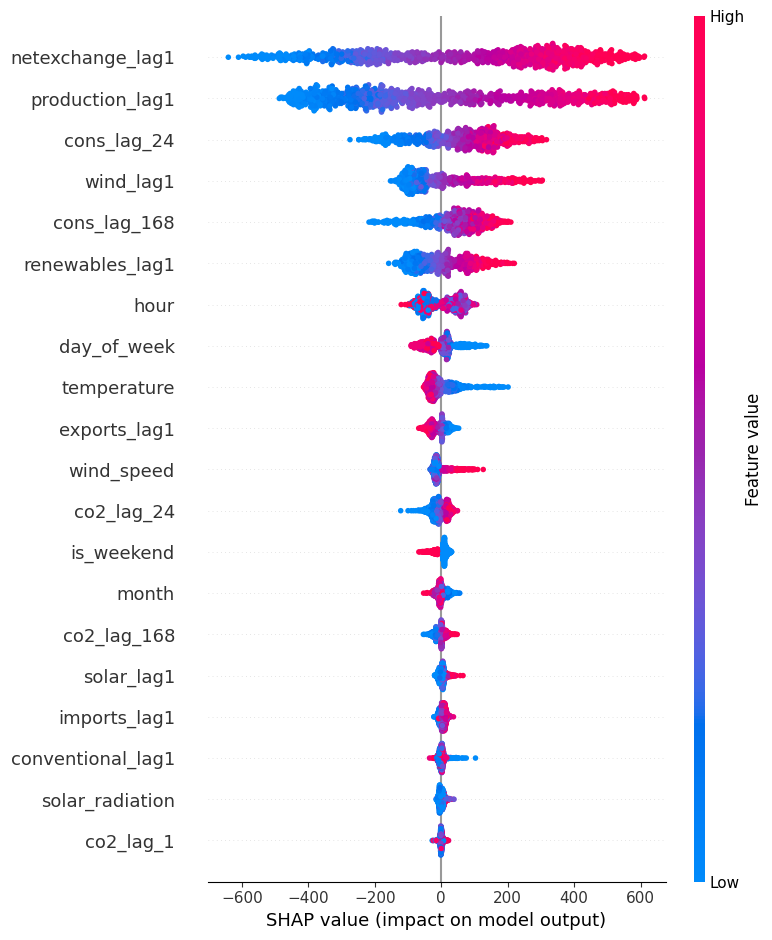

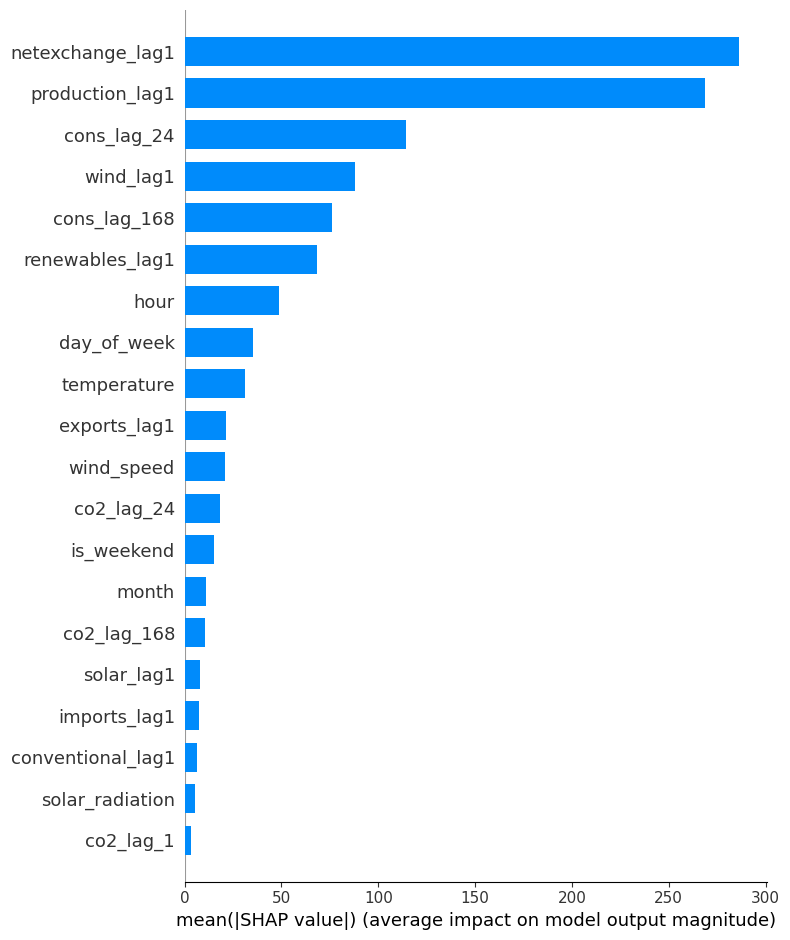

In [22]:
# SHAP ANALYSIS - Consumption Model Without cons_lag_1

# Create SHAP explainer
explainer_cons_no_lag1 = shap.Explainer(best_model_no_lag1, X_train_no_lag1)

# Use a sample from the test set for faster computation
X_sample_cons_no_lag1 = X_test_no_lag1.sample(1000, random_state=42)

# Compute SHAP values
shap_values_cons_no_lag1 = explainer_cons_no_lag1(X_sample_cons_no_lag1)

# Summary plot
shap.summary_plot(shap_values_cons_no_lag1, X_sample_cons_no_lag1)

# Bar plot
shap.summary_plot(shap_values_cons_no_lag1, X_sample_cons_no_lag1, plot_type="bar")

To better understand the drivers of electricity consumption beyond short-term persistence, SHAP analysis was applied to the gradient boosting model after excluding the lag-1 consumption feature. This allows for a clearer assessment of the relative importance of temporal, system, and weather-related variables when the dominant autoregressive signal is removed.

The results indicate that electricity consumption is influenced by a combination of system conditions and temporal patterns. In particular, lagged net exchange and total production emerge as important predictors, suggesting that cross-border flows and generation levels contain informative signals about system demand. These variables should be interpreted as proxies for underlying system conditions rather than direct causal drivers.

Longer-term lagged consumption variables (lag-24 and lag-168) also remain relevant, capturing daily and weekly regularities in demand. Weather-related features, including temperature, wind, and renewable generation, contribute to the model, although their marginal impact is smaller relative to system and lagged variables.

Overall, the results suggest that, once immediate persistence is removed, the model relies on a broader set of variables reflecting system dynamics and recurring temporal patterns, providing a more informative view of the underlying drivers of electricity consumption.

In [23]:
# Final Comparison Table : Electricity Consumption

consumption_results = pd.DataFrame({
    "Model": [
        "Naive Baseline (lag-1)",
        "Naive Baseline (lag-24)",
        "Linear Regression",
        "Gradient Boosting (initial)",
        "Gradient Boosting (tuned final)",
        "Gradient Boosting (no cons_lag_1)"
    ],
    "Validation MAE": [
        val_mae_c_lag1,
        val_mae_c_lag24,
        val_mae_lr,
        val_mae_gb,
        np.nan,
        np.nan
    ],
    "Validation RMSE": [
        val_rmse_c_lag1,
        val_rmse_c_lag24,
        val_rmse_lr,
        val_rmse_gb,
        np.nan,
        np.nan
    ],
    "Test MAE": [
        test_mae_c_lag1,
        test_mae_c_lag24,
        test_mae_lr,
        test_mae_gb,
        final_mae,
        test_mae_no_lag1
    ],
    "Test RMSE": [
        test_rmse_c_lag1,
        test_rmse_c_lag24,
        test_rmse_lr,
        test_rmse_gb,
        final_rmse,
        test_rmse_no_lag1
    ]
})

display(consumption_results.round(2))

,Model,Validation MAE,Validation RMSE,Test MAE,Test RMSE
0,Naive Baseline (lag-1),93.86,120.67,102.63,133.46
1,Naive Baseline (lag-24),258.67,338.63,206.90,285.46
2,Linear Regression,91.96,115.34,85.33,111.62
3,Gradient Boosting (initial),70.01,95.04,68.97,96.92
4,Gradient Boosting (tuned final),NaN,NaN,65.13,92.49
5,Gradient Boosting (no cons_lag_1),NaN,NaN,107.54,145.85


Table  presents the predictive performance of all models for electricity consumption. The results highlight the importance of strong baseline comparisons and the role of temporal dependence in short-term forecasting.
The lag-1 persistence model provides a strong benchmark, achieving a test MAE of approximately 103 MWh, reflecting the high degree of short-term autocorrelation in electricity consumption. In contrast, the lag-24 baseline performs substantially worse, indicating that daily repetition alone is insufficient for accurate one-hour-ahead forecasting.
The linear regression model improves over both baselines, reducing the test MAE to approximately 85 MWh, suggesting that incorporating multiple explanatory variables provides additional predictive value beyond simple persistence.
The gradient boosting model further improves performance, achieving a test MAE of approximately 69 MWh in its initial form and 65 MWh after tuning. This indicates that nonlinear models can capture additional structure in the data, although the improvements remain incremental relative to the strong lag-1 baseline.
Finally, removing the lag-1 feature leads to a substantial deterioration in performance (test MAE ≈ 108 MWh), confirming that short-term persistence is the dominant source of predictive power. This result underscores the importance of lagged information and motivates the use of no-lag-1 models primarily for interpretability rather than predictive accuracy.
Overall, the results suggest that while machine learning models improve upon simple baselines, a large share of forecast accuracy is driven by autoregressive structure, with additional features providing more limited incremental gains.

In [24]:
# Relative improvement over lag-1 baseline: Electricity Consumption

consumption_relative_improvement = pd.DataFrame({
    "Model": [
        "Naive Baseline (lag-24)",
        "Linear Regression",
        "Gradient Boosting (initial)",
        "Gradient Boosting (tuned final)",
        "Gradient Boosting (no cons_lag_1)"
    ],
    "Test MAE": [
        test_mae_c_lag24,
        test_mae_lr,
        test_mae_gb,
        final_mae,
        test_mae_no_lag1
    ],
    "Lag-1 Baseline MAE": [
        test_mae_c_lag1
    ] * 5
})

consumption_relative_improvement["MAE Improvement over Lag-1 (%)"] = (
    (consumption_relative_improvement["Lag-1 Baseline MAE"] - consumption_relative_improvement["Test MAE"])
    / consumption_relative_improvement["Lag-1 Baseline MAE"]
) * 100

display(consumption_relative_improvement.round(2))

,Model,Test MAE,Lag-1 Baseline MAE,MAE Improvement over Lag-1 (%)
0,Naive Baseline (lag-24),206.90,102.63,-101.60
1,Linear Regression,85.33,102.63,16.86
2,Gradient Boosting (initial),68.97,102.63,32.80
3,Gradient Boosting (tuned final),65.13,102.63,36.53
4,Gradient Boosting (no cons_lag_1),107.54,102.63,-4.79



Relative improvements are evaluated against the lag-1 persistence baseline, which serves as a strong benchmark for 1-hour-ahead forecasting.

The lag-24 baseline performs substantially worse, with an error increase of approximately 102%, confirming that short-term persistence is more informative than daily repetition.

Linear regression reduces MAE by approximately 16.9%, while gradient boosting achieves larger improvements, with the tuned model reducing MAE by approximately 36.3%. This indicates that additional features and nonlinear relationships provide meaningful gains beyond persistence.

However, given the strength of the lag-1 baseline, these improvements should be interpreted in relative terms. The model without lag-1 performs slightly worse than persistence, confirming that short-term autoregressive structure remains the dominant predictor.

In [25]:
# Practical comparison: Lag-1 baseline vs tuned Gradient Boosting

mean_consumption = y_test.mean()

consumption_practical_comparison = pd.DataFrame({
    "Model": [
        "Lag-1 Persistence Baseline",
        "Tuned Gradient Boosting"
    ],
    "Average Consumption (MWh)": [
        mean_consumption,
        mean_consumption
    ],
    "Test MAE (MWh)": [
        test_mae_c_lag1,
        final_mae
    ],
    "MAE as % of Average Consumption": [
        (test_mae_c_lag1 / mean_consumption) * 100,
        (final_mae / mean_consumption) * 100
    ]
})

display(consumption_practical_comparison.round(2))

,Model,Average Consumption (MWh),Test MAE (MWh),MAE as % of Average Consumption
0,Lag-1 Persistence Baseline,2748.6,102.63,3.73
1,Tuned Gradient Boosting,2748.6,65.13,2.37


### Practical Significance of Forecast Errors

To better interpret the magnitude of forecasting errors, the final model performance is evaluated relative to the overall scale of electricity consumption.

The average electricity consumption during the test period is approximately 2,749 MWh, while the tuned Gradient Boosting model achieves a mean absolute error of approximately 65 MWh. This corresponds to roughly 2.4% of the average consumption level.

These results suggest that the forecasting errors are relatively small compared to the overall scale of system demand. Therefore, the improvement over the lag-1 persistence baseline appears practically meaningful in the context of short-term electricity consumption forecasting.

In [26]:
# Conditional error analysis: Electricity Consumption

cons_error_analysis = test_df.copy()

cons_error_analysis["actual_consumption"] = y_test.values
cons_error_analysis["predicted_consumption"] = y_test_pred_final
cons_error_analysis["abs_error"] = np.abs(
    cons_error_analysis["actual_consumption"] - cons_error_analysis["predicted_consumption"]
)

# 1. Error by hour of day
cons_error_by_hour = (
    cons_error_analysis
    .groupby("hour")["abs_error"]
    .mean()
    .reset_index()
)

cons_error_by_hour.columns = ["hour", "MAE"]

display(cons_error_by_hour.round(2))

,hour,MAE
0,0,81.42
1,1,58.23
2,2,49.90
3,3,55.08
4,4,55.99
5,5,60.97
6,6,72.93
7,7,64.05
8,8,58.53
9,9,57.07


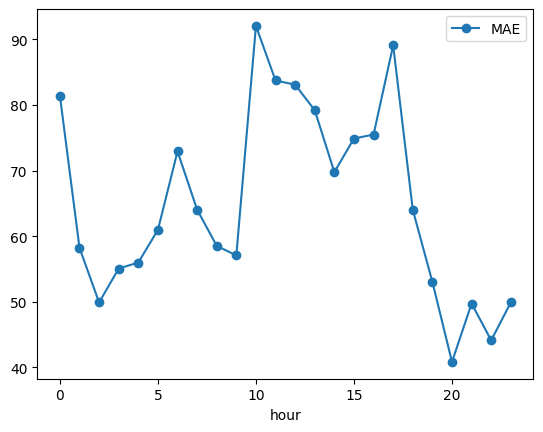

In [52]:
cons_error_by_hour.plot(x="hour", y="MAE", kind="line", marker="o")

plt.savefig("cons_error_by_hour.png", dpi=300, bbox_inches='tight')

plt.show()

In [27]:
# Error by season: Electricity Consumption

def assign_season(row):
    if row["season_spring"] == 1:
        return "spring"
    elif row["season_summer"] == 1:
        return "summer"
    elif row["season_winter"] == 1:
        return "winter"
    else:
        return "autumn"

cons_error_analysis["season"] = cons_error_analysis.apply(assign_season, axis=1)

cons_error_by_season = (
    cons_error_analysis
    .groupby("season")["abs_error"]
    .mean()
    .reset_index()
)

cons_error_by_season.columns = ["season", "MAE"]

display(cons_error_by_season.round(2))

,season,MAE
0,autumn,64.27
1,spring,71.11
2,summer,55.14
3,winter,70.06


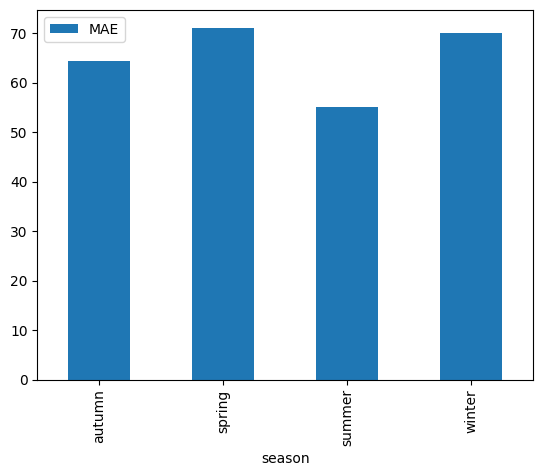

In [53]:
cons_error_by_season.plot(x="season", y="MAE", kind="bar")

plt.savefig("cons_error_by_season.png", dpi=300, bbox_inches='tight')

plt.show()

In [28]:
# Error by lagged renewable generation level: Electricity Consumption

cons_error_analysis["renewable_level"] = pd.qcut(
    cons_error_analysis["renewables_lag1"],
    q=3,
    labels=["Low renewable generation", "Medium renewable generation", "High renewable generation"]
)

cons_error_by_renewables = (
    cons_error_analysis
    .groupby("renewable_level", observed=True)["abs_error"]
    .mean()
    .reset_index()
)

cons_error_by_renewables.columns = ["Renewable generation level", "MAE"]

display(cons_error_by_renewables.round(2))

,Renewable generation level,MAE
0,Low renewable generation,47.92
1,Medium renewable generation,65.62
2,High renewable generation,81.85


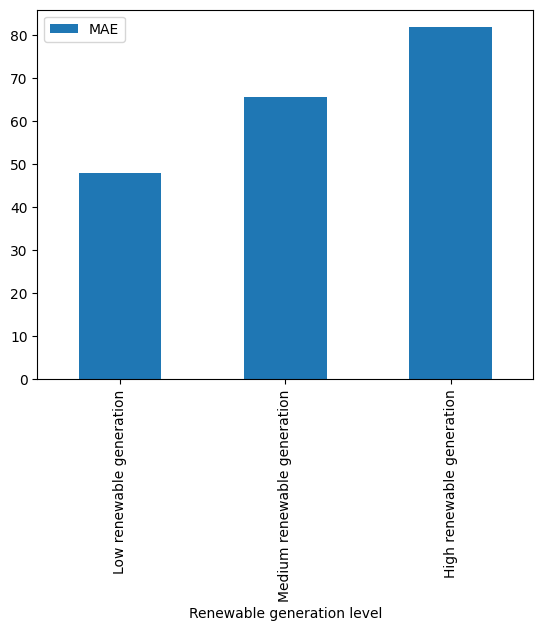

In [54]:
cons_error_by_renewables.plot(
    x="Renewable generation level",
    y="MAE",
    kind="bar"
)

plt.savefig("cons_error_by_renewables.png", dpi=300, bbox_inches='tight')

plt.show()

To further assess model performance, the test errors are analyzed across different temporal and system conditions.

The hourly analysis shows that prediction errors are higher during certain daytime and peak periods, while lower errors are observed during late evening and night hours. This suggests that the model performs better during more stable demand periods and struggles more during periods with higher variability.

Seasonal analysis indicates that errors are higher in winter and spring, and lower in summer. This may reflect increased variability in electricity demand during colder periods, where weather-related effects are more pronounced.

When conditioning on renewable generation levels, errors are lowest during periods of low renewable generation and highest during periods of high renewable generation. This suggests that increased variability associated with renewable production may make electricity consumption more difficult to predict.

Overall, these results indicate that model performance varies systematically across time and system conditions, highlighting the importance of considering conditional performance in addition to aggregate error metrics.

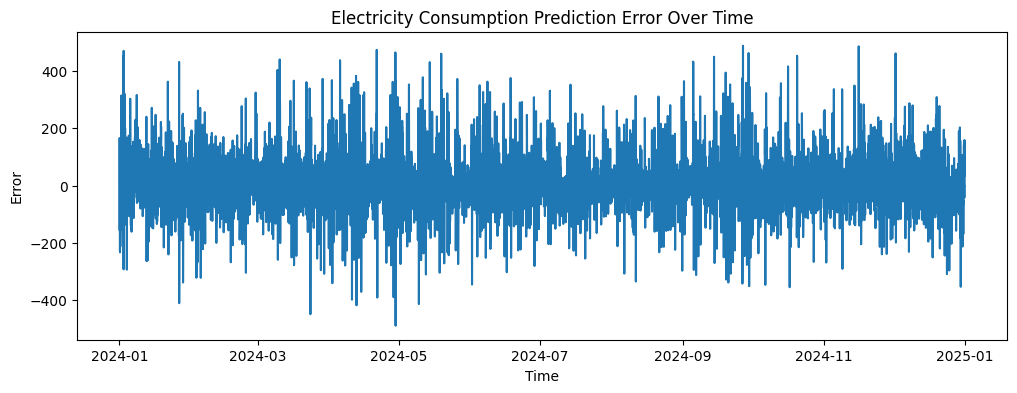

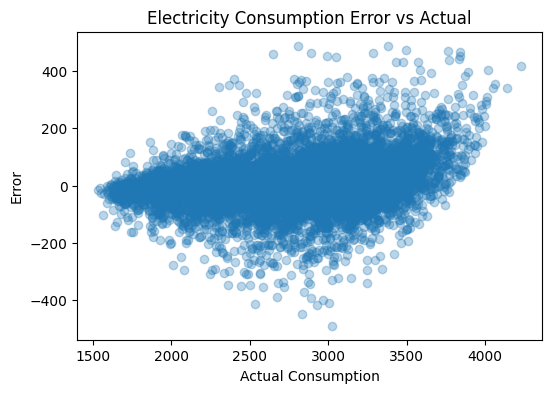

In [29]:
# ERROR ANALYSIS : Electricity Consumption

# Make safe copy
test_df_error = test_df.copy()

# Use final tuned model predictions
test_df_error["error"] = y_test - y_test_pred_final
test_df_error["abs_error"] = test_df_error["error"].abs()

# Error over time
plt.figure(figsize=(12, 4))
plt.plot(test_df_error["datetime_utc"], test_df_error["error"])
plt.title("Electricity Consumption Prediction Error Over Time")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

# Error vs actual
plt.figure(figsize=(6, 4))
plt.scatter(y_test, test_df_error["error"], alpha=0.3)
plt.title("Electricity Consumption Error vs Actual")
plt.xlabel("Actual Consumption")
plt.ylabel("Error")
plt.show()

The error analysis provides additional insight into when the consumption forecasting model performs well or poorly.

The error-over-time plot shows that errors fluctuate around zero, suggesting no strong persistent bias. However, several larger deviations occur, indicating that the model is less accurate during certain periods.

The error-versus-actual plot suggests that errors tend to be larger at higher consumption levels. This indicates that high-demand periods are more difficult to forecast than more typical demand periods.

Overall, the model performs well on average, but its accuracy varies across operating conditions, especially during higher-demand periods.

In [30]:

# CO2 MODEL: Define X and y

# Target variable
y_co2 = model_df['co2_intensity']

# Feature matrix (same features as before)
X_co2 = model_df[feature_cols]

print("CO2 Model - Feature shape:", X_co2.shape)
print("CO2 Model - Target shape:", y_co2.shape)

CO2 Model - Feature shape: (26135, 24)
CO2 Model - Target shape: (26135,)


A separate model is constructed to forecast CO₂ intensity using the same feature engineering framework as the electricity consumption model. The target variable is CO₂ intensity, while the feature set includes lagged variables, time-based features, weather variables, and lagged system-related variables.

In [31]:
# CO2 MODEL : Time Split

train_df_co2 = model_df[model_df['datetime_utc'] < "2023-10-01"].copy()

val_df_co2 = model_df[
    (model_df['datetime_utc'] >= "2023-10-01") &
    (model_df['datetime_utc'] < "2024-01-01")
].copy()

test_df_co2 = model_df[model_df['datetime_utc'] >= "2024-01-01"].copy() 

# Split X and y
X_train_co2 = train_df_co2[feature_cols]
y_train_co2 = train_df_co2['co2_intensity']

X_val_co2 = val_df_co2[feature_cols]
y_val_co2 = val_df_co2['co2_intensity']

X_test_co2 = test_df_co2[feature_cols]
y_test_co2 = test_df_co2['co2_intensity']

# Check
print("Train shape:", X_train_co2.shape)
print("Validation shape:", X_val_co2.shape)
print("Test shape:", X_test_co2.shape)

Train shape: (15143, 24)
Validation shape: (2208, 24)
Test shape: (8784, 24)


### Predictive Modelling Setup (with lag-1)

In [32]:
# CO2 MODEL : Baselines (lag-1 and lag-24)

# Baseline 1: lag-1 persistence
y_val_pred_base_co2_lag1 = X_val_co2['co2_lag_1']
y_test_pred_base_co2_lag1 = X_test_co2['co2_lag_1']

# Baseline 2: lag-24 persistence
y_val_pred_base_co2_lag24 = X_val_co2['co2_lag_24']
y_test_pred_base_co2_lag24 = X_test_co2['co2_lag_24']

# Evaluation: lag-1
val_mae_co2_lag1 = mean_absolute_error(y_val_co2, y_val_pred_base_co2_lag1)
val_rmse_co2_lag1 = np.sqrt(mean_squared_error(y_val_co2, y_val_pred_base_co2_lag1))

test_mae_co2_lag1 = mean_absolute_error(y_test_co2, y_test_pred_base_co2_lag1)
test_rmse_co2_lag1 = np.sqrt(mean_squared_error(y_test_co2, y_test_pred_base_co2_lag1))

# Evaluation: lag-24
val_mae_co2_lag24 = mean_absolute_error(y_val_co2, y_val_pred_base_co2_lag24)
val_rmse_co2_lag24 = np.sqrt(mean_squared_error(y_val_co2, y_val_pred_base_co2_lag24))

test_mae_co2_lag24 = mean_absolute_error(y_test_co2, y_test_pred_base_co2_lag24)
test_rmse_co2_lag24 = np.sqrt(mean_squared_error(y_test_co2, y_test_pred_base_co2_lag24))

print("CO2 Baseline (lag-1) Validation MAE:", val_mae_co2_lag1)
print("CO2 Baseline (lag-1) Validation RMSE:", val_rmse_co2_lag1)
print("CO2 Baseline (lag-1) Test MAE:", test_mae_co2_lag1)
print("CO2 Baseline (lag-1) Test RMSE:", test_rmse_co2_lag1)

print("\nCO2 Baseline (lag-24) Validation MAE:", val_mae_co2_lag24)
print("CO2 Baseline (lag-24) Validation RMSE:", val_rmse_co2_lag24)
print("CO2 Baseline (lag-24) Test MAE:", test_mae_co2_lag24)
print("CO2 Baseline (lag-24) Test RMSE:", test_rmse_co2_lag24)

CO2 Baseline (lag-1) Validation MAE: 13.624131944444445
CO2 Baseline (lag-1) Validation RMSE: 22.261896220319493
CO2 Baseline (lag-1) Test MAE: 15.516943685488766
CO2 Baseline (lag-1) Test RMSE: 24.06054827125176

CO2 Baseline (lag-24) Validation MAE: 53.02313556763285
CO2 Baseline (lag-24) Validation RMSE: 72.55631508574189
CO2 Baseline (lag-24) Test MAE: 52.47320886460231
CO2 Baseline (lag-24) Test RMSE: 68.64902212268304


The lag-1 persistence model provides a strong baseline for CO₂ intensity, achieving a test MAE of approximately 15.5 and an RMSE of approximately 24.1, reflecting substantial short-term temporal dependence.

In contrast, the lag-24 baseline performs considerably worse (test MAE ≈ 52.5, RMSE ≈ 68.6), indicating that daily repetition alone does not adequately capture short-term variability in CO₂ intensity.

In [33]:
#Linear Regression Model for co2
model_lr_co2 = LinearRegression()
model_lr_co2.fit(X_train_co2, y_train_co2)

# Validation
y_val_pred_lr_co2 = model_lr_co2.predict(X_val_co2)

# Test
y_test_pred_lr_co2 = model_lr_co2.predict(X_test_co2)


print("Linear Regression CO2 Validation MAE:", mean_absolute_error(y_val_co2, y_val_pred_lr_co2))
print("Linear Regression CO2 Validation RMSE:", np.sqrt(mean_squared_error(y_val_co2, y_val_pred_lr_co2)))

print("\nLinear Regression CO2 Test MAE:", mean_absolute_error(y_test_co2, y_test_pred_lr_co2))
print("Linear Regression CO2 Test RMSE:", np.sqrt(mean_squared_error(y_test_co2, y_test_pred_lr_co2)))

Linear Regression CO2 Validation MAE: 15.34973701330962
Linear Regression CO2 Validation RMSE: 22.40387235395855

Linear Regression CO2 Test MAE: 16.00676663580245
Linear Regression CO2 Test RMSE: 23.313359804110572


The linear regression model achieves a test MAE of approximately 16.0 and an RMSE of approximately 23.3, performing similarly to the lag-1 persistence baseline (MAE ≈ 15.5, RMSE ≈ 24.1). This suggests that most of the predictive structure in CO₂ intensity is already captured by short-term temporal dependence.

While linear regression provides a substantial improvement over the lag-24 baseline, it offers only limited additional predictive value beyond the lag-1 model. This indicates that, in this setting, simple autoregressive information explains a large share of the forecast accuracy.

In [34]:
## Gradient Boosting (Basic Model)
model_gb_co2 = GradientBoostingRegressor(random_state=42)
model_gb_co2.fit(X_train_co2, y_train_co2)

# Validation
y_val_pred_gb_co2 = model_gb_co2.predict(X_val_co2)

# Test
y_test_pred_gb_co2 = model_gb_co2.predict(X_test_co2)

print("Gradient Boosting CO2 Validation MAE:", mean_absolute_error(y_val_co2, y_val_pred_gb_co2))
print("Gradient Boosting CO2 Validation RMSE:", np.sqrt(mean_squared_error(y_val_co2, y_val_pred_gb_co2)))

print("\nGradient Boosting CO2 Test MAE:", mean_absolute_error(y_test_co2, y_test_pred_gb_co2))
print("Gradient Boosting CO2 Test RMSE:", np.sqrt(mean_squared_error(y_test_co2, y_test_pred_gb_co2)))

Gradient Boosting CO2 Validation MAE: 14.714013312676808
Gradient Boosting CO2 Validation RMSE: 22.412615678956218

Gradient Boosting CO2 Test MAE: 15.751601896381233
Gradient Boosting CO2 Test RMSE: 23.207109528032092


The initial gradient boosting model achieves a test MAE of approximately 15.75 and an RMSE of approximately 23.20, showing performance comparable to both the lag-1 baseline and the linear regression model.

While the model improves substantially over the lag-24 baseline, the gains relative to lag-1 are minimal, indicating that most predictive information is already captured by short-term persistence. This suggests that the additional model complexity provides only limited incremental benefit in this setting.

In [35]:
# CO2 MODEL - Gradient Boosting Hyperparameter Tuning

results_co2 = []

for n_estimators in [100, 200]:
    for max_depth in [2, 3, 5]:
        for learning_rate in [0.05, 0.1]:
            
            model = GradientBoostingRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                random_state=42
            )
            
            model.fit(X_train_co2, y_train_co2)
            y_val_pred = model.predict(X_val_co2)
            val_mae = mean_absolute_error(y_val_co2, y_val_pred)
            
            results_co2.append({
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "learning_rate": learning_rate,
                "val_mae": val_mae
            })

results_co2_df = pd.DataFrame(results_co2).sort_values("val_mae")
print(results_co2_df)

    n_estimators  max_depth  learning_rate    val_mae
8            200          3           0.05  14.673609
3            100          3           0.10  14.714013
7            200          2           0.10  14.732214
9            200          3           0.10  14.772914
1            100          2           0.10  14.808625
2            100          3           0.05  14.818744
4            100          5           0.05  14.844472
6            200          2           0.05  14.855881
10           200          5           0.05  14.953271
5            100          5           0.10  15.079995
0            100          2           0.05  15.090950
11           200          5           0.10  15.527976


Hyperparameter tuning was performed for the Gradient Boosting model using the validation set while preserving temporal ordering. A small grid of values for the number of estimators, tree depth, and learning rate was evaluated. The best-performing configuration was selected based on validation MAE.

In [36]:
# FINAL CO2 MODEL (Tuned GB)
best_gb_co2 = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

# Train on TRAIN + VALIDATION
X_train_full_co2 = pd.concat([X_train_co2, X_val_co2])
y_train_full_co2 = pd.concat([y_train_co2, y_val_co2])

best_gb_co2.fit(X_train_full_co2, y_train_full_co2)

# Test prediction
y_test_pred_final_co2 = best_gb_co2.predict(X_test_co2)

print("FINAL CO2 MODEL TEST MAE:", mean_absolute_error(y_test_co2, y_test_pred_final_co2))
print("FINAL CO2 MODEL TEST RMSE:", np.sqrt(mean_squared_error(y_test_co2, y_test_pred_final_co2)))

FINAL CO2 MODEL TEST MAE: 15.700321175886325
FINAL CO2 MODEL TEST RMSE: 23.17681920995234


After hyperparameter tuning, the final gradient boosting model achieves a test MAE of approximately 15.70 and an RMSE of approximately 23.16, representing only a marginal improvement over the initial model.

The performance remains very close to both the lag-1 baseline and the linear regression model, indicating that additional model complexity yields limited gains. This further supports the observation that short-term persistence accounts for a large share of the predictive structure in CO₂ intensity.

The naive lag-1 model achieves the lowest MAE, indicating that CO₂ intensity is strongly driven by short-term persistence. While Gradient Boosting yields a slightly lower RMSE, the difference is small, suggesting that the overall predictive performance of both models is very similar.

Given the strong dominance of lag-1 persistence, Gradient Boosting is not used as the primary forecasting model. Instead, it is analyzed as a complementary model to explore how exogenous variables are utilized within a more flexible modelling framework.

In [37]:
feature_importance_co2 = pd.DataFrame({
    'feature': X_train_co2.columns,
    'importance': best_gb_co2.feature_importances_
}).sort_values(by='importance', ascending=False)

print(feature_importance_co2.head(10))

              feature  importance
10          co2_lag_1    0.984664
22       exports_lag1    0.001829
19  conventional_lag1    0.001716
11         co2_lag_24    0.001648
3                hour    0.001500
16          wind_lag1    0.001474
18    renewables_lag1    0.001212
2     solar_radiation    0.000931
21       imports_lag1    0.000644
0         temperature    0.000630


The feature importance analysis shows that co2_lag_1 overwhelmingly dominates the model, accounting for approximately 98% of total importance. This indicates that short-term temporal dependence is the primary driver of predictive performance for CO₂ intensity.
All other variables contribute only marginally. Among these, lagged system variables such as exports, conventional generation, and renewables, as well as co2_lag_24, have small but non-negligible contributions. Weather-related features, including wind and solar radiation, exhibit limited importance.
Overall, the results suggest that the model relies almost entirely on autoregressive structure, with other variables providing only minimal incremental information once lag-1 is included.

In [38]:
# CO2 MODEL : SHAP Analysis

# Create explainer for the tuned CO2 model
explainer_co2 = shap.Explainer(best_gb_co2, X_train_co2)

# Use a sample from the test set for faster SHAP computation
X_sample_co2 = X_test_co2.sample(1000, random_state=42)

# Compute SHAP values
shap_values_co2 = explainer_co2(X_sample_co2)

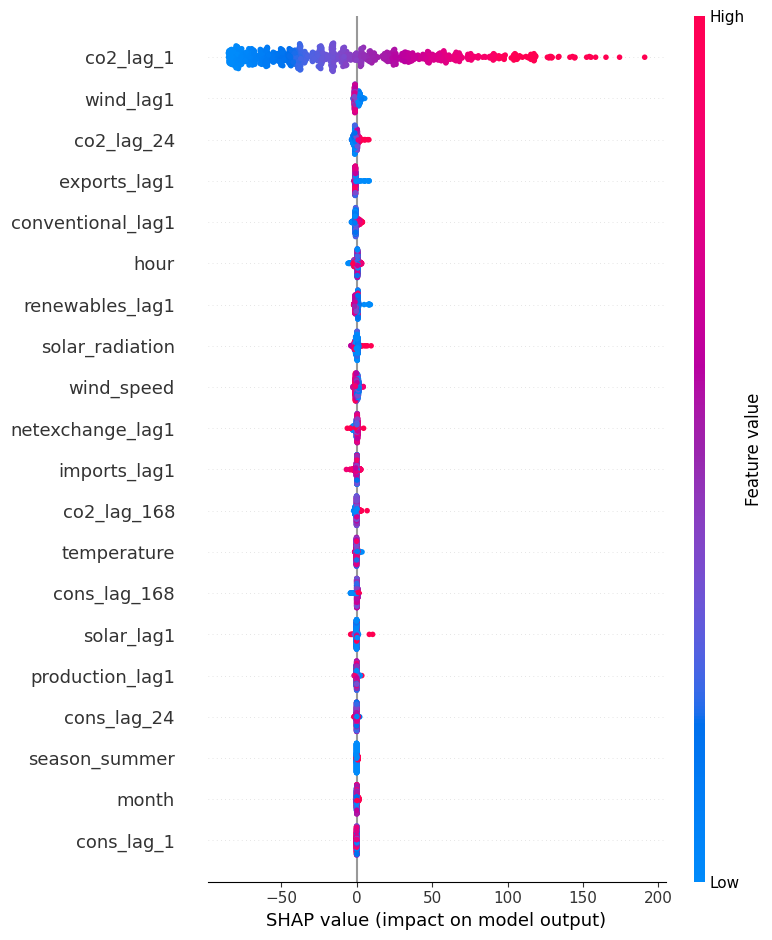

In [39]:
# SHAP summary plot
shap.summary_plot(shap_values_co2, X_sample_co2)

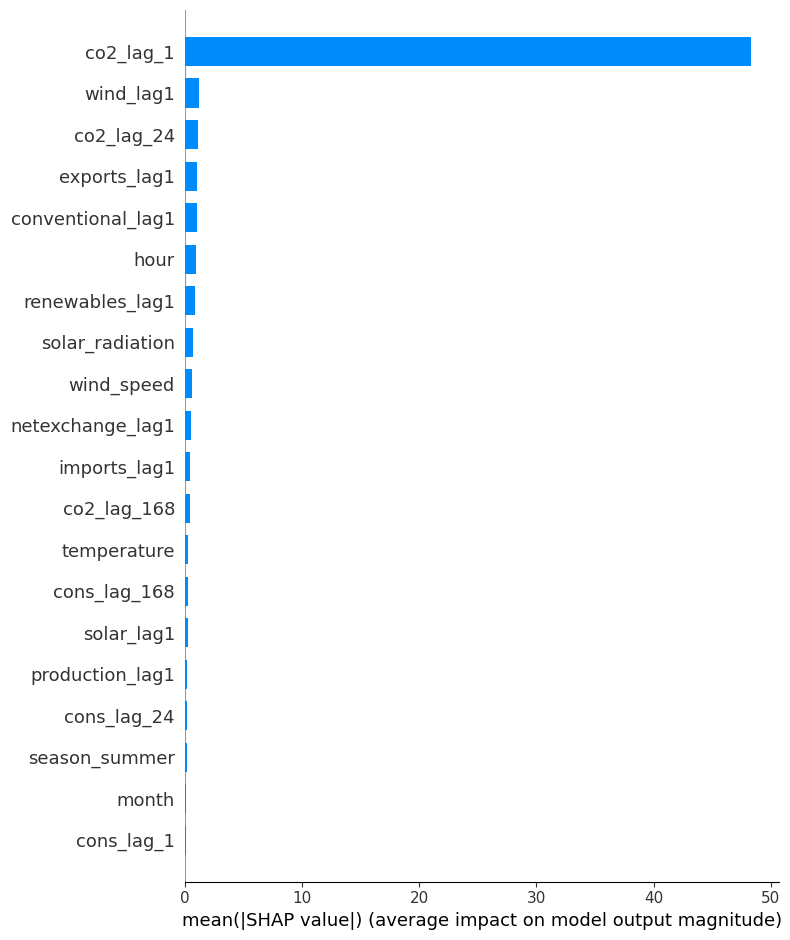

In [40]:
# SHAP bar plot
shap.summary_plot(shap_values_co2, X_sample_co2, plot_type="bar")

The SHAP analysis confirms that co2_lag_1 is the dominant predictor, exhibiting by far the largest contribution to model output. The summary plot shows a clear monotonic relationship, where higher lag-1 values lead to higher predicted CO₂ intensity, reinforcing the strong short-term persistence observed in earlier results.
All other features have comparatively small SHAP values, indicating limited marginal influence once lag-1 is included. Among these, lagged system variables such as wind, conventional generation, and renewables show minor contributions, while temporal features (e.g., hour) and weather variables (solar radiation, temperature) have only weak effects.
Overall, the SHAP results suggest that the model relies predominantly on autoregressive structure, with additional variables contributing only marginally to prediction when immediate persistence is available.

### Diagnostic Modelling Setup (without lag-1)

In [41]:
# CO2 MODEL EXPERIMENT: remove co2_lag_1
feature_cols_co2_no_lag1 = [col for col in feature_cols if col != "co2_lag_1"]

X_train_co2_no_lag1 = train_df_co2[feature_cols_co2_no_lag1]
X_val_co2_no_lag1 = val_df_co2[feature_cols_co2_no_lag1]
X_test_co2_no_lag1 = test_df_co2[feature_cols_co2_no_lag1]

print("Number of features without co2_lag_1:", len(feature_cols_co2_no_lag1))
print(feature_cols_co2_no_lag1)

Number of features without co2_lag_1: 23
['temperature', 'wind_speed', 'solar_radiation', 'hour', 'day_of_week', 'month', 'is_weekend', 'season_spring', 'season_summer', 'season_winter', 'co2_lag_24', 'co2_lag_168', 'cons_lag_1', 'cons_lag_24', 'cons_lag_168', 'wind_lag1', 'solar_lag1', 'renewables_lag1', 'conventional_lag1', 'production_lag1', 'imports_lag1', 'exports_lag1', 'netexchange_lag1']


In [42]:
# CO2 MODEL (NO LAG1) - TUNING

results_no_lag1 = []

for n_estimators in [100, 200]:
    for max_depth in [2, 3, 5]:
        for learning_rate in [0.05, 0.1]:
            
            model = GradientBoostingRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                random_state=42
            )
            
            model.fit(X_train_co2_no_lag1, y_train_co2)
            y_val_pred = model.predict(X_val_co2_no_lag1)
            
            val_mae = mean_absolute_error(y_val_co2, y_val_pred)
            
            results_no_lag1.append({
                "n_estimators": n_estimators,
                "max_depth": max_depth,
                "learning_rate": learning_rate,
                "val_mae": val_mae
            })

results_no_lag1_df = pd.DataFrame(results_no_lag1).sort_values("val_mae")
print(results_no_lag1_df)

    n_estimators  max_depth  learning_rate    val_mae
3            100          3           0.10  42.999870
7            200          2           0.10  43.010112
8            200          3           0.05  43.283068
11           200          5           0.10  43.437984
4            100          5           0.05  43.852573
9            200          3           0.10  43.857430
6            200          2           0.05  43.970914
1            100          2           0.10  44.075736
10           200          5           0.05  44.100398
5            100          5           0.10  44.245281
2            100          3           0.05  44.280401
0            100          2           0.05  45.891235


In [43]:
# FINAL CO2 MODEL (NO LAG1)

best_gb_no_lag1 = GradientBoostingRegressor(
    n_estimators=200,
    max_depth=2,
    learning_rate=0.10,
    random_state=42
)

# Train on train + validation
X_train_full_no_lag1 = pd.concat([X_train_co2_no_lag1, X_val_co2_no_lag1])
y_train_full_no_lag1 = pd.concat([y_train_co2, y_val_co2])

best_gb_no_lag1.fit(X_train_full_no_lag1, y_train_full_no_lag1)

# Test prediction
y_test_pred_no_lag1 = best_gb_no_lag1.predict(X_test_co2_no_lag1)

print("NO-LAG1 CO2 TEST MAE:", mean_absolute_error(y_test_co2, y_test_pred_no_lag1))
print("NO-LAG1 CO2 TEST RMSE:", np.sqrt(mean_squared_error(y_test_co2, y_test_pred_no_lag1)))

NO-LAG1 CO2 TEST MAE: 36.73535413224049
NO-LAG1 CO2 TEST RMSE: 45.75962777395931


To assess the role of short-term persistence, the lag-1 feature was removed from the model. This leads to a substantial decline in performance, with the test MAE increasing from approximately 15.7 to 37.0 and the RMSE to approximately 46.0, confirming the dominant role of immediate temporal dependence.

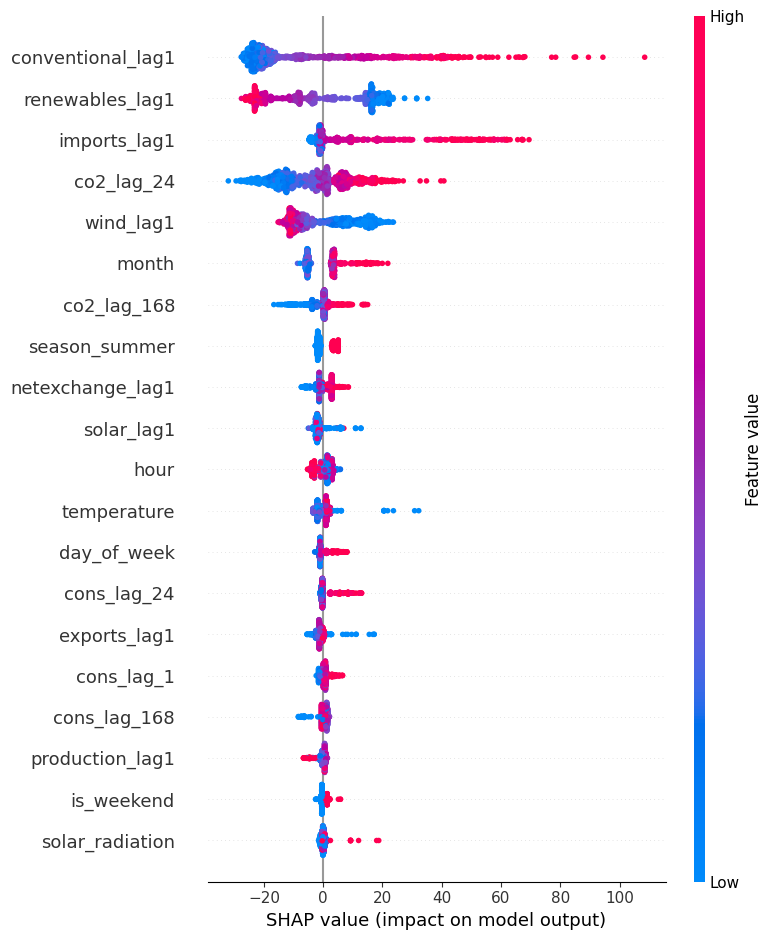

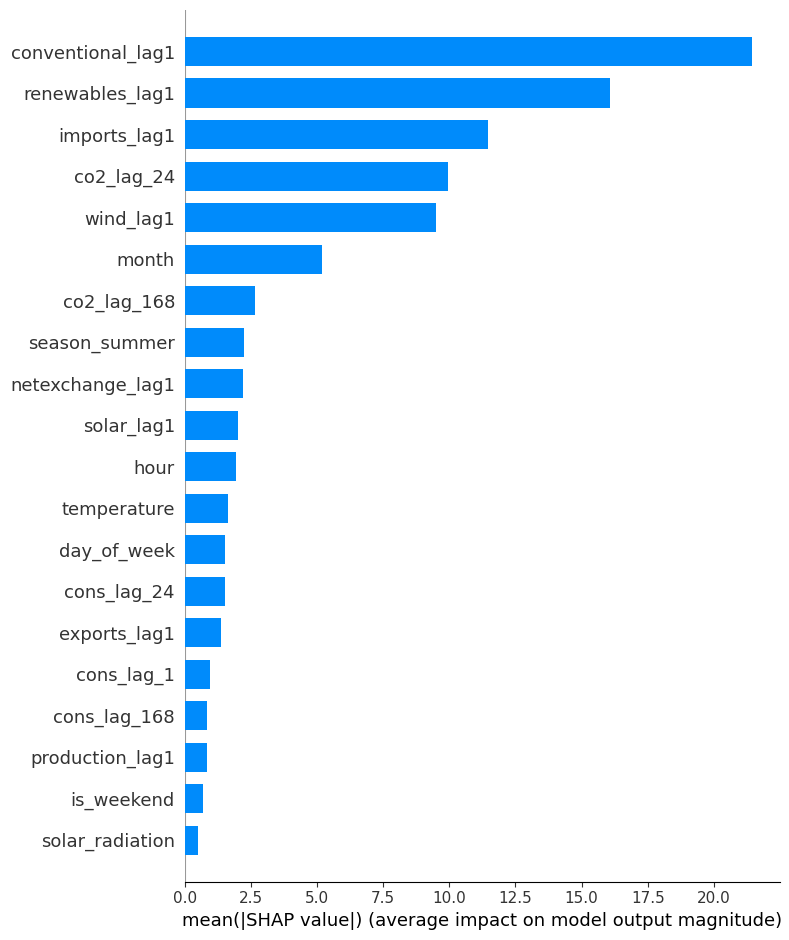

In [44]:
# shap analysis
explainer_no_lag1 = shap.Explainer(best_gb_no_lag1, X_train_co2_no_lag1)

X_sample_no_lag1 = X_test_co2_no_lag1.sample(1000, random_state=42)

shap_values_no_lag1 = explainer_no_lag1(X_sample_no_lag1)

# Summary plot
shap.summary_plot(shap_values_no_lag1, X_sample_no_lag1)

# Bar plot
shap.summary_plot(shap_values_no_lag1, X_sample_no_lag1, plot_type="bar")

To examine the role of non-autoregressive predictors, SHAP analysis was applied to the CO₂ gradient boosting model after excluding co2_lag_1. This no-lag-1 specification is interpreted as a diagnostic sensitivity analysis rather than the main operational forecasting model.

The results indicate that lagged system variables, including conventional generation, renewable production, imports,lagged wind and lagged CO₂ values, become more important when immediate persistence is removed. These variables should be interpreted as predictors used by the model and as proxies for system conditions, not as causal drivers.

This analysis highlights the trade-off between predictive performance and interpretability. The lag-1 model provides the strongest short-term forecast, while the no-lag-1 model gives a clearer view of secondary variables associated with CO₂ intensity.

In [45]:
# Final Comparison Table - CO2 Intensity

co2_results = pd.DataFrame({
    "Model": [
        "Naive Baseline (lag-1)",
        "Naive Baseline (lag-24)",
        "Linear Regression",
        "Gradient Boosting (initial)",
        "Gradient Boosting (tuned final)",
        "Gradient Boosting (no co2_lag_1)"
    ],
    "Validation MAE": [
        val_mae_co2_lag1,
        val_mae_co2_lag24,
        mean_absolute_error(y_val_co2, y_val_pred_lr_co2),
        mean_absolute_error(y_val_co2, y_val_pred_gb_co2),
        np.nan,
        np.nan
    ],
    "Validation RMSE": [
        val_rmse_co2_lag1,
        val_rmse_co2_lag24,
        np.sqrt(mean_squared_error(y_val_co2, y_val_pred_lr_co2)),
        np.sqrt(mean_squared_error(y_val_co2, y_val_pred_gb_co2)),
        np.nan,
        np.nan
    ],
    "Test MAE": [
        test_mae_co2_lag1,
        test_mae_co2_lag24,
        mean_absolute_error(y_test_co2, y_test_pred_lr_co2),
        mean_absolute_error(y_test_co2, y_test_pred_gb_co2),
        mean_absolute_error(y_test_co2, y_test_pred_final_co2),
        mean_absolute_error(y_test_co2, y_test_pred_no_lag1)
    ],
    "Test RMSE": [
        test_rmse_co2_lag1,
        test_rmse_co2_lag24,
        np.sqrt(mean_squared_error(y_test_co2, y_test_pred_lr_co2)),
        np.sqrt(mean_squared_error(y_test_co2, y_test_pred_gb_co2)),
        np.sqrt(mean_squared_error(y_test_co2, y_test_pred_final_co2)),
        np.sqrt(mean_squared_error(y_test_co2, y_test_pred_no_lag1))
    ]
})

display(co2_results.round(2))

,Model,Validation MAE,Validation RMSE,Test MAE,Test RMSE
0,Naive Baseline (lag-1),13.62,22.26,15.52,24.06
1,Naive Baseline (lag-24),53.02,72.56,52.47,68.65
2,Linear Regression,15.35,22.40,16.01,23.31
3,Gradient Boosting (initial),14.71,22.41,15.75,23.21
4,Gradient Boosting (tuned final),NaN,NaN,15.70,23.18
5,Gradient Boosting (no co2_lag_1),NaN,NaN,36.74,45.76


Table summarizes the predictive performance of all models for CO₂ intensity. The results highlight the strong role of short-term temporal dependence in this forecasting task.

The lag-1 persistence model provides the strongest baseline, achieving a test MAE of approximately 15.5 and RMSE of approximately 24.1, indicating that immediate past values contain most of the predictive information. In contrast, the lag-24 baseline performs substantially worse, confirming that daily repetition alone is insufficient for accurate short-term forecasting.

Both linear regression and gradient boosting achieve performance comparable to the lag-1 baseline, with only marginal differences in error metrics. Hyperparameter tuning leads to only minor improvements, suggesting that increased model complexity does not translate into substantial gains in predictive accuracy for this task.

Finally, removing the lag-1 feature results in a significant decline in performance (test MAE ≈ 37.0), reinforcing the conclusion that short-term persistence is the dominant driver of predictive accuracy. However, the model without lag-1 still outperforms the lag-24 baseline, indicating that additional features contribute meaningful, albeit secondary, information.

Overall, these results suggest that CO₂ intensity is largely predictable through short-term autoregressive structure, with more complex models providing only limited incremental improvements.

In [46]:
# Relative improvement over lag-1 baseline: CO₂ Intensity

co2_relative_improvement = pd.DataFrame({
    "Model": [
        "Naive Baseline (lag-24)",
        "Linear Regression",
        "Gradient Boosting (initial)",
        "Gradient Boosting (tuned final)",
        "Gradient Boosting (no co2_lag_1)"
    ],
    "Test MAE": [
        test_mae_co2_lag24,
        mean_absolute_error(y_test_co2, y_test_pred_lr_co2),
        mean_absolute_error(y_test_co2, y_test_pred_gb_co2),
        mean_absolute_error(y_test_co2, y_test_pred_final_co2),
        mean_absolute_error(y_test_co2, y_test_pred_no_lag1)
    ],
    "Lag-1 Baseline MAE": [
        test_mae_co2_lag1
    ] * 5
})

co2_relative_improvement["MAE Improvement over Lag-1 (%)"] = (
    (co2_relative_improvement["Lag-1 Baseline MAE"] - co2_relative_improvement["Test MAE"])
    / co2_relative_improvement["Lag-1 Baseline MAE"]
) * 100

display(co2_relative_improvement.round(2))

,Model,Test MAE,Lag-1 Baseline MAE,MAE Improvement over Lag-1 (%)
0,Naive Baseline (lag-24),52.47,15.52,-238.17
1,Linear Regression,16.01,15.52,-3.16
2,Gradient Boosting (initial),15.75,15.52,-1.51
3,Gradient Boosting (tuned final),15.70,15.52,-1.18
4,Gradient Boosting (no co2_lag_1),36.74,15.52,-136.74


Relative improvements are evaluated against the lag-1 persistence baseline, which provides a strong benchmark for short-term CO₂ forecasting.

All models perform very similarly to the lag-1 baseline, with small negative improvements ranging from approximately -1% to -3%. This indicates that more complex models do not provide meaningful gains over simple persistence for CO₂ intensity at the 1-hour horizon.

The lag-24 baseline performs substantially worse, confirming that short-term persistence is far more informative than daily repetition. Removing the lag-1 feature leads to a large deterioration in performance, further highlighting that short-term autoregressive structure is the dominant predictor.

Overall, these results show that CO₂ intensity is largely driven by persistence, with only limited incremental value from additional features or model complexity.

In [47]:
# Practical comparison: Lag-1 baseline vs tuned Gradient Boosting (CO2)

mean_co2 = y_test_co2.mean()

co2_practical_comparison = pd.DataFrame({
    "Model": [
        "Lag-1 Persistence Baseline",
        "Tuned Gradient Boosting"
    ],
    "Average CO2 Intensity": [
        mean_co2,
        mean_co2
    ],
    "Test MAE": [
        test_mae_co2_lag1,
        mean_absolute_error(y_test_co2, y_test_pred_final_co2)
    ],
    "MAE as % of Average CO2 Intensity": [
        (test_mae_co2_lag1 / mean_co2) * 100,
        (mean_absolute_error(y_test_co2, y_test_pred_final_co2) / mean_co2) * 100
    ]
})

display(co2_practical_comparison.round(2))

,Model,Average CO2 Intensity,Test MAE,MAE as % of Average CO2 Intensity
0,Lag-1 Persistence Baseline,103.02,15.52,15.06
1,Tuned Gradient Boosting,103.02,15.70,15.24


Practical Comparison with the Lag-1 Persistence Baseline

Table  compares the practical forecasting performance of the lag-1 persistence baseline and the tuned Gradient Boosting model for CO₂ intensity forecasting.

The average CO₂ intensity during the test period is approximately 103 gCO₂/kWh. The lag-1 persistence baseline achieves a test MAE corresponding to approximately 15.1% of the average CO₂ intensity, while the tuned Gradient Boosting model achieves a very similar error level of approximately 15.2%.

These results suggests that the additional complexity of the Gradient Boosting model does not provide a practically meaningful improvement over the simple lag-1 persistence baseline.

In [48]:
# Conditional error analysis: CO₂ Intensity using lag-1 persistence baseline

co2_error_analysis = test_df.copy()

co2_error_analysis["actual_co2"] = y_test_co2.values
co2_error_analysis["predicted_co2_lag1"] = X_test_co2["co2_lag_1"].values

co2_error_analysis["abs_error"] = np.abs(
    co2_error_analysis["actual_co2"] - co2_error_analysis["predicted_co2_lag1"]
)

# Error by hour of day
co2_error_by_hour = (
    co2_error_analysis
    .groupby("hour")["abs_error"]
    .mean()
    .reset_index()
)

co2_error_by_hour.columns = ["hour", "MAE"]

display(co2_error_by_hour.round(2))

,hour,MAE
0,0,16.36
1,1,13.08
2,2,11.84
3,3,11.59
4,4,11.74
5,5,14.50
6,6,17.90
7,7,14.77
8,8,17.11
9,9,18.00


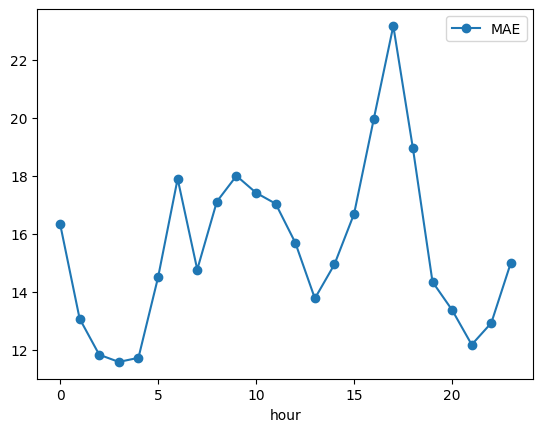

In [55]:
co2_error_by_hour.plot(x="hour", y="MAE", kind="line", marker="o")

plt.savefig("co2_error_by_hour.png", dpi=300, bbox_inches='tight')

plt.show()

In [49]:
# Error by season: CO₂ Intensity using lag-1 persistence baseline

def assign_season(row):
    if row["season_spring"] == 1:
        return "spring"
    elif row["season_summer"] == 1:
        return "summer"
    elif row["season_winter"] == 1:
        return "winter"
    else:
        return "autumn"

co2_error_analysis["season"] = co2_error_analysis.apply(assign_season, axis=1)

co2_error_by_season = (
    co2_error_analysis
    .groupby("season")["abs_error"]
    .mean()
    .reset_index()
)

co2_error_by_season.columns = ["season", "MAE"]

display(co2_error_by_season.round(2))

,season,MAE
0,autumn,14.56
1,spring,17.06
2,summer,19.25
3,winter,11.14


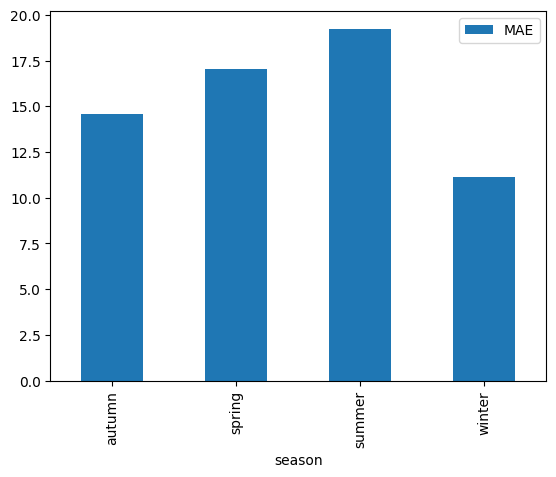

In [56]:
co2_error_by_season.plot(x="season", y="MAE", kind="bar")

plt.savefig("co2_error_by_season.png", dpi=300, bbox_inches='tight')

plt.show()

In [50]:
# Error by lagged renewable generation level: CO₂ Intensity using lag-1 persistence baseline

co2_error_analysis["renewable_level"] = pd.qcut(
    co2_error_analysis["renewables_lag1"],
    q=3,
    labels=["Low renewable generation", "Medium renewable generation", "High renewable generation"]
)

co2_error_by_renewables = (
    co2_error_analysis
    .groupby("renewable_level", observed=True)["abs_error"]
    .mean()
    .reset_index()
)

co2_error_by_renewables.columns = ["Renewable generation level", "MAE"]

display(co2_error_by_renewables.round(2))

,Renewable generation level,MAE
0,Low renewable generation,19.22
1,Medium renewable generation,17.13
2,High renewable generation,10.19


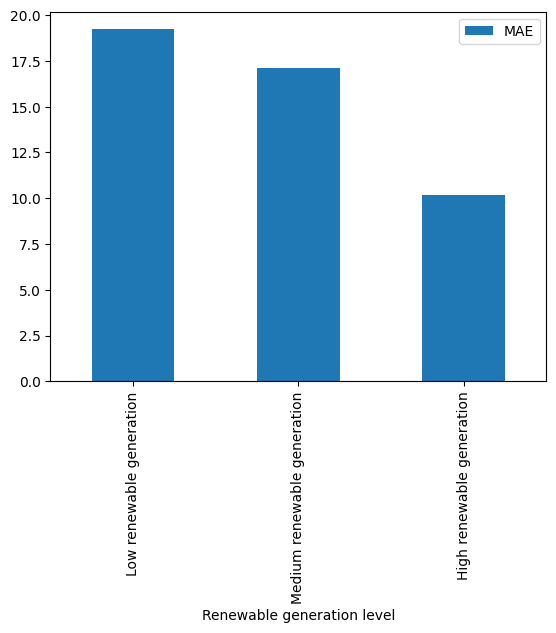

In [57]:
co2_error_by_renewables.plot(
    x="Renewable generation level",
    y="MAE",
    kind="bar"
)

plt.savefig("co2_error_by_renewables.png", dpi=300, bbox_inches='tight')

plt.show()

Since the lag-1 persistence baseline provides the strongest overall performance for CO₂ intensity, the conditional error analysis is based on this model. The aim is to examine whether persistence-based forecasting errors vary across temporal and system conditions.

The hourly results show that errors vary across the day, with higher errors during some afternoon and early evening hours. This suggests that CO₂ intensity is less stable during certain parts of the day, even when using the most recent observed value as the forecast.

Seasonal results indicate that errors are lowest in winter and highest in summer. This suggests that the stability of CO₂ intensity differs across seasons, although these patterns should be interpreted descriptively rather than causally.

When conditioning on lagged renewable generation, errors are lowest during high renewable generation periods and highest during low renewable generation periods. This indicates that short-term persistence performs better when renewable generation is high, while CO₂ intensity appears less predictable during low-renewable periods.

Overall, the results show that even the strong lag-1 persistence benchmark does not perform uniformly across all conditions. This supports the use of conditional error analysis alongside aggregate MAE and RMSE metrics.

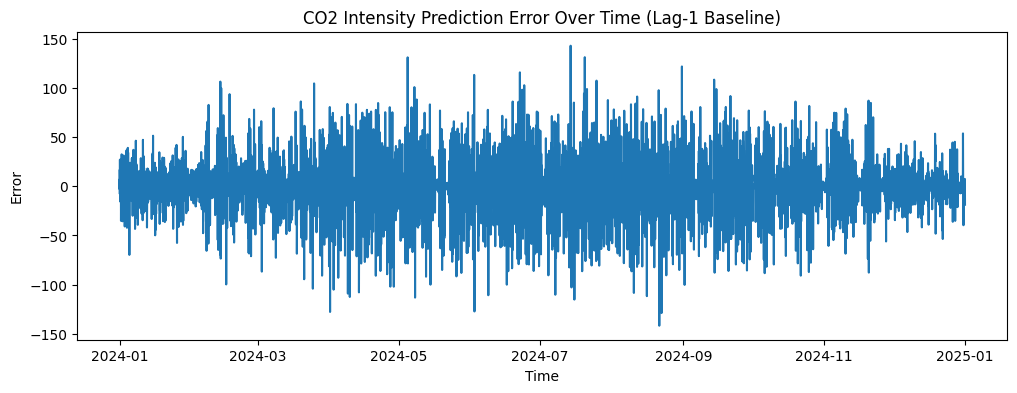

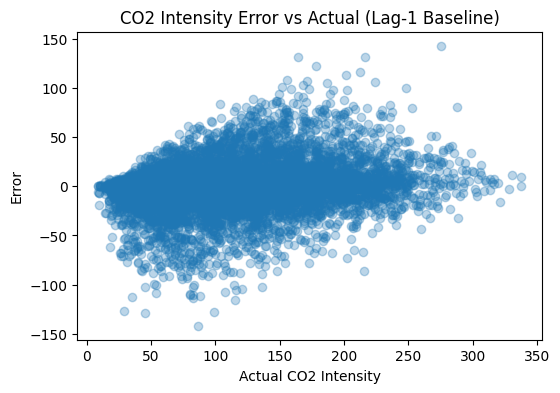

In [51]:
# ERROR ANALYSIS - CO2 Intensity
# Best model: lag-1 persistence baseline

test_df_co2_error = test_df_co2.copy()

# Use lag-1 persistence predictions
y_test_pred_co2_best = X_test_co2["co2_lag_1"].values

test_df_co2_error["error"] = y_test_co2.values - y_test_pred_co2_best
test_df_co2_error["abs_error"] = np.abs(test_df_co2_error["error"])

# Error over time
plt.figure(figsize=(12, 4))
plt.plot(test_df_co2_error["datetime_utc"], test_df_co2_error["error"])
plt.title("CO2 Intensity Prediction Error Over Time (Lag-1 Baseline)")
plt.xlabel("Time")
plt.ylabel("Error")
plt.show()

# Error vs actual
plt.figure(figsize=(6, 4))
plt.scatter(y_test_co2, test_df_co2_error["error"], alpha=0.3)
plt.title("CO2 Intensity Error vs Actual (Lag-1 Baseline)")
plt.xlabel("Actual CO2 Intensity")
plt.ylabel("Error")
plt.show()

Error analysis is conducted using the lag-1 persistence baseline, which provides the best overall forecasting performance for CO₂ intensity.

The error over time fluctuates around zero, indicating no strong systematic bias. However, periods of increased variability are observed, suggesting that prediction accuracy deteriorates during more volatile system conditions.

The error versus actual values plot shows increasing dispersion at higher CO₂ intensity levels. This indicates that the persistence-based model is less accurate when CO₂ intensity is high, reflecting greater variability in the underlying system.

Overall, the results suggest that while lag-1 persistence provides strong average performance, prediction errors increase during periods of higher system variability, particularly at elevated CO₂ intensity levels.

## Key Findings:
1. Electricity consumption benefits meaningfully from nonlinear models, although lag-1 persistence remains a strong benchmark.

2. CO₂ intensity forecasting is strongly dominated by short-term persistence.

3. Gradient Boosting does not provide a practically meaningful improvement over the lag-1 persistence baseline for CO₂ intensity forecasting.

4. Lag-1 is the dominant predictor in both forecasting tasks.

5. Removing lag-1 helps reveal secondary predictors such as lagged system variables, weather variables, and calendar effects.